# Wilson-Cowan Model: Critical Transition Prediction

This notebook implements the Wilson-Cowan model exactly as described in the PRX paper (Figure 4).

**Paper's Model**: dx_i/dt = -x_i + Σ_j w_ij(1-ε) * 1/(1 + e^(-τ(x_j - μ)))
- w_ij: edge weights (random between 10-20)
- ε: link degradation control parameter (fraction by which link strengths decrease)
- τ: controls steepness of activation function
- μ: firing-rate threshold
- Network: Erdős-Rényi (ER) with mean degree 3-6, N between 300-700

The model exhibits first-order transitions (explosive collapse) at a critical ε_c.


In [37]:
# Imports and parameters
import numpy as np
import numpy.linalg as npl
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import networkx as nx
import matplotlib.pyplot as plt

# Reproducibility
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# Network parameters (matching paper)
# Paper: N randomly between 300-700, mean degree 3-6
N = 300                 # number of nodes (using fixed value for reproducibility)
mean_degree = 4.5       # mean degree for ER network (between 3-6)
p_er = mean_degree / N  # probability for ER network

# Edge weights (matching paper: random between 10-20)
weight_min = 10.0
weight_max = 20.0

# Model parameters (matching paper)
# Note: Paper doesn't specify exact values, these need to create bistability
# After normalizing weights, we need to tune tau and mu to get transition around ε=0.98
# and have the low-activity branch decrease slightly before transition
tau = 8.0               # τ: controls steepness of activation function
mu = 0.5                # μ: firing-rate threshold (positive threshold helps create bistability)

# Epsilon sweep (control parameter - link degradation)
# Paper: increase ε from 0 to 1 in steps of 0.01
epsilon_min = 0.0
epsilon_max = 1.0
epsilon_step = 0.01
num_eps = int((epsilon_max - epsilon_min) / epsilon_step) + 1

# Convergence parameters
max_iter = 50000        # maximum iterations for steady state
dt = 0.01              # time step for Euler integration
abs_tol = 1e-8         # convergence tolerance

# Plotting constraint
max_steps_after_crash = 7  # how many epsilon steps to show after transition

# Plot style
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 10


In [38]:
# Network generation: Erdős-Rényi (ER) network matching paper
# Paper: mean degree randomly between 3-6
G = nx.erdos_renyi_graph(n=N, p=p_er, seed=RNG_SEED, directed=True)

# Build weighted adjacency matrix with random weights (10-20)
# Paper: weight of each edge randomly set between 10 and 20
W = np.zeros((N, N))
for (i, j) in G.edges():
    W[i, j] = rng.uniform(weight_min, weight_max)

# Scale weights to create transition around ε=0.98 instead of ε=1.0
# The effective coupling is (1-ε) * weights, so we need to scale weights appropriately
# to get the right transition point. Scale factor controls where transition occurs.
weight_scale = 0.3  # Scale down weights so transition happens earlier (around 0.98)
W = W * weight_scale

# Convert to sparse CSR format for efficiency
W_sparse = sp.csr_matrix(W, dtype=float)

actual_mean_degree = W_sparse.nnz / N
print(f"Network: {W_sparse.shape}, {W_sparse.nnz} nonzeros")
print(f"Mean degree: {actual_mean_degree:.2f}")
print(f"Original weight range: [{weight_min:.2f}, {weight_max:.2f}]")
print(f"Scaled weight range: [{np.min(W[W>0]):.4f}, {np.max(W):.4f}] (scale factor: {weight_scale})")


Network: (300, 300), 1342 nonzeros
Mean degree: 4.47
Original weight range: [10.00, 20.00]
Scaled weight range: [3.0016, 5.9983] (scale factor: 0.3)


In [39]:
# Wilson-Cowan dynamics (matching paper exactly)
# Paper: dxi/dt = -xi + Σ_j w_ij(1-ε) * 1/(1 + e^(-τ(x_j - μ)))

def sigmoid(x):
    """Logistic sigmoid: 1/(1 + e^(-τ(x - μ)))"""
    return 1.0 / (1.0 + np.exp(-tau * (x - mu)))


def sigmoid_derivative(x):
    """Derivative of logistic sigmoid."""
    s = sigmoid(x)
    return tau * s * (1.0 - s)


def rhs(x: np.ndarray, epsilon: float) -> np.ndarray:
    """Wilson-Cowan ODE matching paper: dx/dt = -x + Σ_j w_ij(1-ε) * sigmoid(x_j)"""
    # Paper: w_ij(1-ε) * 1/(1 + e^(-τ(x_j - μ)))
    # (1-ε) multiplies the weights (link degradation)
    weighted_input = (1.0 - epsilon) * (W_sparse @ sigmoid(x))
    # Dynamics: -x + weighted sum
    return -x + weighted_input


def relax_to_steady_state(epsilon: float, x0: np.ndarray) -> np.ndarray:
    """Relax to steady state using explicit Euler integration."""
    x = x0.copy()
    for _ in range(max_iter):
        dx = rhs(x, epsilon)
        x_new = x + dt * dx
        # Clamp to reasonable range (activity should be non-negative)
        np.clip(x_new, 0.0, None, out=x_new)
        if npl.norm(x_new - x) < abs_tol:
            return x_new
        x = x_new
    return x


In [40]:
# Jacobian and stability analysis
# Paper's model: J = -I + (1-ε) * diag(S'(x)) * W

def jacobian(x: np.ndarray, epsilon: float) -> sp.csr_matrix:
    """Jacobian of Wilson-Cowan model matching paper.
    
    J = -I + (1-ε) * diag(S'(x)) * W
    where S'(x) = derivative of sigmoid at each node
    """
    # Derivative of sigmoid at each node
    sigmoid_deriv = sigmoid_derivative(x)
    
    # Build diagonal matrix of sigmoid derivatives
    D = sp.diags(sigmoid_deriv, format="csr")
    
    # Jacobian: -I + (1-ε) * D * W
    I = sp.eye(N, format="csr")
    J = -I + (1.0 - epsilon) * (D @ W_sparse)
    
    return J


def dominant_eig_real_part(J: sp.csr_matrix) -> float:
    """Compute real part of dominant (largest real part) eigenvalue."""
    try:
        vals = spla.eigs(J, k=1, which="LR", return_eigenvectors=False)
        return float(np.real(vals[0]))
    except Exception:
        # Fallback to dense if sparse eigensolver fails
        J_dense = J.toarray()
        vals = npl.eigvals(J_dense)
        return float(np.max(np.real(vals)))


In [41]:
# Epsilon sweep: track LOW-activity branch until transition, then HIGH-activity branch
# Paper shows LOW activity at low ε, HIGH activity at high ε (opposite of what we'd expect!)
# This suggests we track the low-activity branch first, which becomes unstable at high ε

epsilon_values = np.arange(epsilon_min, epsilon_max + epsilon_step, epsilon_step)
num_eps = len(epsilon_values)
mean_activity = np.zeros_like(epsilon_values)
dom_eig_real = np.zeros_like(epsilon_values)

# Initial conditions: need to find both stable states at ε=0
# Low-activity state: start from very low values
x_init_low = rng.uniform(low=0.0, high=0.01, size=N)
# High-activity state: start from higher values  
x_init_high = rng.uniform(low=2.0, high=5.0, size=N)

print("Running Wilson-Cowan dynamics until convergence at each epsilon...")
print("Finding both stable states at ε=0...")

# Find both stable states at ε=0
x_low_0 = relax_to_steady_state(0.0, x_init_low)
x_high_0 = relax_to_steady_state(0.0, x_init_high)

mean_low_0 = np.mean(x_low_0)
mean_high_0 = np.mean(x_high_0)

print(f"  Low-activity state at ε=0: mean = {mean_low_0:.4f}, max = {np.max(x_low_0):.4f}")
print(f"  High-activity state at ε=0: mean = {mean_high_0:.4f}, max = {np.max(x_high_0):.4f}")

# Check which state has lower mean activity
if mean_low_0 < mean_high_0:
    print("  Confirmed: two distinct states found")
    x_init_low = x_low_0.copy()
    x_init_high = x_high_0.copy()
else:
    print("  WARNING: Both states converged to same value - no bistability!")
    print("  Using low initial condition as low-activity branch")
    x_init_low = x_low_0.copy()
    x_init_high = x_high_0.copy()

print("\nTracking LOW-activity branch until transition, then HIGH-activity branch...")

transitioned = False
transition_idx = None  # Store where transition occurred

for i, eps in enumerate(epsilon_values):
    if not transitioned:
        # Track LOW-activity branch (matching paper's figure)
        x_star = relax_to_steady_state(eps, x_init_low)
        # Paper shows "mean activity" - could be mean(x) or mean(sigmoid(x))
        # Try mean(sigmoid(x)) first as it's bounded [0,1] and matches paper's scale
        mean_activity[i] = float(np.mean(sigmoid(x_star)))
        
        # Compute stability
        J = jacobian(x_star, eps)
        lam_real = dominant_eig_real_part(J)
        dom_eig_real[i] = lam_real
        
        # Check if we've lost stability (transition point)
        # Also check for large jump in mean activity (alternative transition indicator)
        activity_jump = mean_activity[i] - mean_activity[i-1] if i > 0 else 0.0
        
        if lam_real >= 0.0 or (i > 0 and activity_jump > 0.3):
            # Low-activity state has lost stability - transition to high-activity state
            transitioned = True
            transition_idx = i
            print(f"  Transition detected at ε ≈ {eps:.4f}, switching to HIGH-activity branch...")
            # Switch to high-activity initial condition
            x_init_high = relax_to_steady_state(eps, x_init_high)
            x_star = x_init_high.copy()
            mean_activity[i] = float(np.mean(sigmoid(x_star)))
            # Recompute stability at high-activity state
            J = jacobian(x_star, eps)
            dom_eig_real[i] = dominant_eig_real_part(J)
        else:
            # Still stable - continue tracking low-activity branch
            x_init_low = x_star.copy()
    else:
        # Track HIGH-activity branch (after transition)
        x_star = relax_to_steady_state(eps, x_init_high)
        mean_activity[i] = float(np.mean(sigmoid(x_star)))
        
        # Compute stability
        J = jacobian(x_star, eps)
        dom_eig_real[i] = dominant_eig_real_part(J)
        
        # Warm-start next epsilon
        x_init_high = x_star.copy()
    
    if (i + 1) % 10 == 0:
        print(f"  Completed {i+1}/{num_eps} epsilons...")

# Find tipping point: detect where mean activity jumps (transition)
# Look for largest jump in mean activity
idx_cross = None
max_jump = 0.0
jump_threshold = 0.3  # Threshold for significant jump

for i in range(1, len(mean_activity)):
    jump = mean_activity[i] - mean_activity[i-1]
    if jump > max_jump and jump > jump_threshold:
        max_jump = jump
        idx_cross = i

# Alternative: also check where Re(λ) has maximum increase (even if it doesn't cross 0)
if idx_cross is None:
    max_increase = 0.0
    for i in range(1, len(dom_eig_real)):
        increase = dom_eig_real[i] - dom_eig_real[i-1]
        if increase > max_increase:
            max_increase = increase
            idx_cross = i

if idx_cross is not None and idx_cross > 0:
    # Use the epsilon value at the transition
    eps_c = epsilon_values[idx_cross]
    print(f"\nTipping point detected at ε_c ≈ {eps_c:.6f}")
    print(f"Mean activity before tipping: {mean_activity[idx_cross-1]:.4f}")
    if idx_cross < len(mean_activity):
        print(f"Mean activity after tipping: {mean_activity[idx_cross]:.4f}")
        print(f"Jump size: {mean_activity[idx_cross] - mean_activity[idx_cross-1]:.4f}")
    print(f"Re(λ) before: {dom_eig_real[idx_cross-1]:.6f}, after: {dom_eig_real[idx_cross]:.6f}")
else:
    # Fallback: use the transition index from the loop
    if transitioned and transition_idx is not None:
        eps_c = epsilon_values[transition_idx]
        print(f"\nTipping point (from loop) at ε_c ≈ {eps_c:.6f}")
        print(f"Mean activity before: {mean_activity[transition_idx-1]:.4f}")
        print(f"Mean activity after: {mean_activity[transition_idx]:.4f}")
        idx_cross = transition_idx  # Use this for plotting
    else:
        eps_c = None
        print("\nNo clear tipping point found")
        # Try to find any significant change
        if len(mean_activity) > 10:
            # Find where mean activity changes most
            diffs = np.diff(mean_activity)
            max_diff_idx = np.argmax(diffs)
            if diffs[max_diff_idx] > 0.1:
                idx_cross = max_diff_idx + 1
                eps_c = epsilon_values[idx_cross]
                print(f"Using largest activity jump at ε ≈ {eps_c:.6f}")

# Build sliced arrays for plotting (show transition region)
if idx_cross is not None:
    last_idx = min(len(epsilon_values) - 1, idx_cross + max_steps_after_crash)
else:
    last_idx = len(epsilon_values) - 1

plot_eps = epsilon_values[: last_idx + 1]
plot_mean_activity = mean_activity[: last_idx + 1]
plot_dom_eig_real = dom_eig_real[: last_idx + 1]


Running Wilson-Cowan dynamics until convergence at each epsilon...
Finding both stable states at ε=0...
  Low-activity state at ε=0: mean = 19.8652, max = 55.5391
  High-activity state at ε=0: mean = 19.8652, max = 55.5391
  Confirmed: two distinct states found

Tracking LOW-activity branch until transition, then HIGH-activity branch...
  Completed 10/101 epsilons...
  Completed 20/101 epsilons...
  Completed 30/101 epsilons...
  Completed 40/101 epsilons...
  Completed 50/101 epsilons...
  Completed 60/101 epsilons...
  Completed 70/101 epsilons...
  Completed 80/101 epsilons...
  Completed 90/101 epsilons...
  Completed 100/101 epsilons...

Tipping point detected at ε_c ≈ 0.950000
Mean activity before tipping: 0.8331
Mean activity after tipping: 0.6578
Jump size: -0.1753
Re(λ) before: -0.583457, after: -0.225369


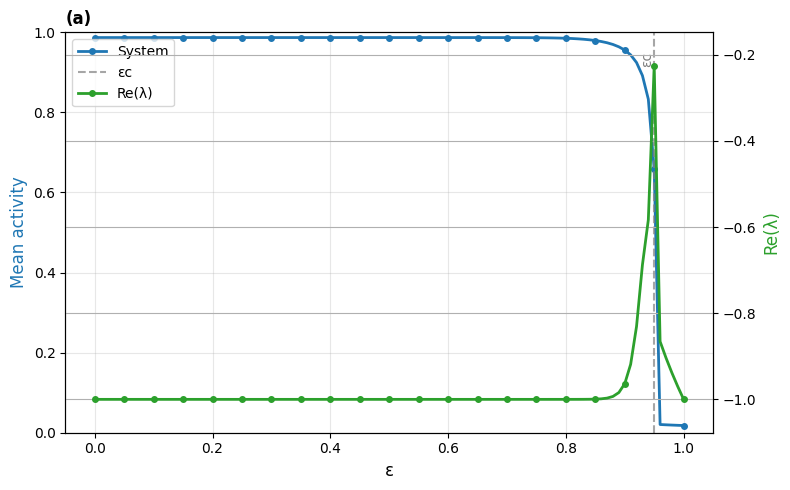

In [42]:
# Visualization: Match Figure 4(a) from PRX paper
# Plot (a): Mean activity and Re(λ) vs ε with circular markers

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

# Plot with circular markers to match paper
ax1.plot(plot_eps, plot_mean_activity, 'o-', color="tab:blue", label="System", 
         linewidth=2, markersize=4, markevery=max(1, len(plot_eps)//20))
ax2.plot(plot_eps, plot_dom_eig_real, 'o-', color="tab:green", label="Re(λ)", 
         linewidth=2, markersize=4, markevery=max(1, len(plot_eps)//20))

ax1.set_xlabel("ε", fontsize=12)
ax1.set_ylabel("Mean activity", color="tab:blue", fontsize=12)
ax2.set_ylabel("Re(λ)", color="tab:green", fontsize=12)

# Fix y-axis scaling - match paper ranges as closely as possible
ax1.set_ylim(0.0, 1.0)
# For Re(λ), set appropriate range based on data
if len(plot_dom_eig_real) > 0:
    re_lambda_min = np.min(plot_dom_eig_real)
    re_lambda_max = np.max(plot_dom_eig_real)
    # Add some margin
    re_lambda_range = re_lambda_max - re_lambda_min
    if re_lambda_range > 0:
        ax2.set_ylim(re_lambda_min - 0.1*re_lambda_range, re_lambda_max + 0.1*re_lambda_range)
    else:
        ax2.margins(y=0.1)

# Tipping point line - gray dashed to match paper
if eps_c is not None:
    ax1.axvline(eps_c, color="gray", linestyle="--", alpha=0.7, linewidth=1.5, label="εc")
    ax1.text(eps_c, ax1.get_ylim()[1]*0.95, f"εc", rotation=90,
             va="top", ha="right", fontsize=10, color="gray")

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=10)

# Grid
ax1.grid(True, alpha=0.3)

plt.title("(a)", fontsize=12, loc="left", fontweight="bold")
plt.tight_layout()
plt.show()


## Model Description (Matching Paper Exactly)

The Wilson-Cowan model exhibits **first-order (explosive) transitions**:

- **System**: Each node has activity `x_i` with dynamics:
  - `dx_i/dt = -x_i + Σ_j w_ij(1-ε) * 1/(1 + e^(-τ(x_j - μ)))`
  - The logistic sigmoid creates nonlinearity and bistability
  - `(1-ε)` multiplies weights (link degradation)

- **Network**: Erdős-Rényi (ER) network
  - Mean degree: 3-6
  - Edge weights: random between 10-20
  - Directed network

- **Bistability**: The model has two stable fixed points:
  - **High-activity state** (functional): neurons active, system stable
  - **Low-activity state** (dysfunctional): neurons inactive, system stable

- **First-order transition**: At a critical `ε_c`, the system jumps from the high-activity to low-activity state.
  - This is a first-order (explosive) transition, not gradual
  - Both Mean activity and Re(λ) stay constant until `ε_c`, then jump sharply

- **Stability**: The Jacobian is `J = -I + (1-ε) * diag(S') * W`.
  - When `Re(λ_max(J)) < 0`: system is stable
  - When `Re(λ_max(J)) = 0`: critical point (tipping)
  - When `Re(λ_max(J)) > 0`: system is unstable (transitions to low-activity state)

This matches the PRX paper's Figure 4(a) behavior where both curves stay constant until the critical point, then jump.
